# Oil Prices Query — Brent vs. WTI

Queries the two major crude oil benchmarks through the `macro_data` package: **Brent** (`brent_oil`, Yahoo ticker `BZ=F`) and **WTI** (`wti_oil`, Yahoo ticker `CL=F`), then plots them together. Both are already quoted in USD/bbl, so no normalization is needed to compare them on one chart.

This is a simple fetch → load → plot notebook (same style as `data_gathering_demo.ipynb` §2/§4) — no trend analysis (moving averages, volatility) or spread calculation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from macro_data import update, load

pd.set_option("display.max_rows", 20)
%matplotlib inline

yahoo_status = update("yahoo")  # refreshes all yahoo series, including brent_oil and wti_oil
print("yahoo:", yahoo_status)

yahoo: {'usd_thb': 'up-to-date', 'eur_usd': 'up-to-date', 'gold_usd': 'up-to-date', 'brent_oil': 'up-to-date', 'wti_oil': 'up-to-date', 'sp500': 'up-to-date', 'set_index': 'up-to-date', 'usd_dxy': 'up-to-date', 'eur_thb': 'up-to-date', 'jpy_thb': 'up-to-date', 'gbp_thb': 'up-to-date', 'us_3m_yield': 'up-to-date', 'us_5y_yield': 'up-to-date', 'us_10y_yield': 'up-to-date', 'us_30y_yield': 'up-to-date'}


## Load & recent values

In [2]:
brent = load("brent_oil")
wti = load("wti_oil")

print("Brent (BZ=F):")
display(brent.tail())
print("WTI (CL=F):")
display(wti.tail())

Brent (BZ=F):


,value
date,
2026-07-08,78.019997
2026-07-09,76.300003
2026-07-10,76.260002
2026-07-13,83.300003
2026-07-15,85.870003


WTI (CL=F):


,value
date,
2026-07-09,72.080002
2026-07-10,71.410004
2026-07-13,78.139999
2026-07-14,79.339996
2026-07-15,79.839996


## Chart

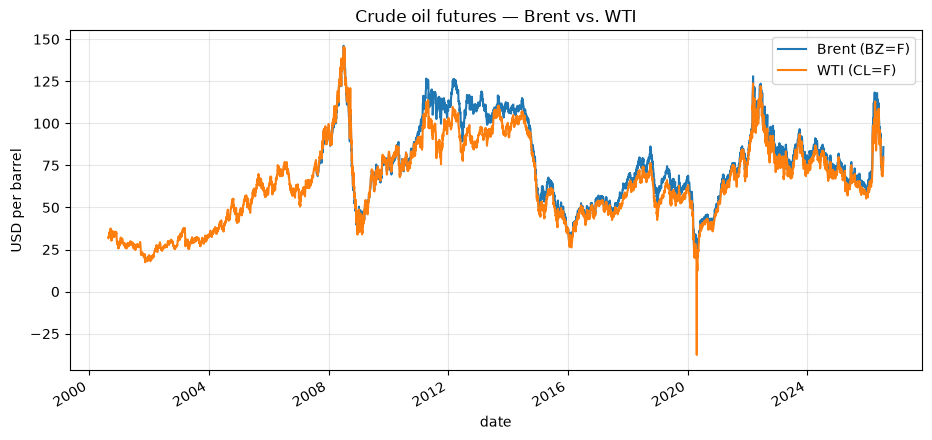

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
brent["value"].plot(ax=ax, label="Brent (BZ=F)")
wti["value"].plot(ax=ax, label="WTI (CL=F)")
ax.set_title("Crude oil futures — Brent vs. WTI")
ax.set_ylabel("USD per barrel")
ax.legend()
ax.grid(alpha=0.3)
plt.show()